# Titanic Survival Prediction — Section B: From-Scratch Implementations

NumPy-only implementations of logistic regression (no regularisation, L1, L2) and two ensemble methods (bagging, AdaBoost-style boosting), evaluated on the split produced in `A_minimal_prep_and_split.ipynb`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)

## Load the prepared split

In [ ]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

# Standardise features so gradient descent converges well.
# (Tree-based models are unaffected by this monotonic rescaling.)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train.astype(float))
X_test_s = scaler.transform(X_test.astype(float))

y_train_arr = y_train.to_numpy().astype(float)
y_test_arr = y_test.to_numpy().astype(float)

X_train_s.shape, X_test_s.shape

((712, 8), (179, 8))

## 1. Logistic Regression from scratch

$$\hat{y} = \sigma(\beta_0 + X\beta_1), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

Trained with batch gradient descent on the log-loss, following the same `sigmoid` / `compute_cost` / `compute_gradients` / training-loop pattern used for the single-feature example, generalised to a weight vector `beta1` (one weight per feature) instead of a single scalar. `penalty` adds a regularisation term to the cost and gradient:
- `'none'` — no penalty
- `'l1'` — adds $\frac{\lambda}{m}\sum|\beta_1|$ to the cost (Lasso)
- `'l2'` — adds $\frac{\lambda}{2m}\sum\beta_1^2$ to the cost (Ridge)

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
def compute_cost(y_hat, Y, beta1, penalty='none', lambda_reg=0.0):
    eps = 1e-12
    pos_component = np.sum(Y * np.log(y_hat + eps))
    neg_component = np.sum((1 - Y) * np.log(1 - y_hat + eps))

    m = len(Y)
    cost = (-1 / m) * (pos_component + neg_component)

    if penalty == 'l1':
        cost += (lambda_reg / m) * np.sum(np.abs(beta1))
    elif penalty == 'l2':
        cost += (lambda_reg / (2 * m)) * np.sum(beta1 ** 2)

    return cost

In [ ]:
def compute_gradients(X, Y, y_hat, beta1, penalty='none', lambda_reg=0.0):
    m = len(Y)

    """
    beta0, beta1
    """

    dJ_dbeta1 = (1 / m) * X.T.dot(y_hat - Y)
    dJ_dbeta0 = (1 / m) * np.sum(y_hat - Y)

    if penalty == 'l1':
        dJ_dbeta1 = dJ_dbeta1 + (lambda_reg / m) * np.sign(beta1)
    elif penalty == 'l2':
        dJ_dbeta1 = dJ_dbeta1 + (lambda_reg / m) * beta1

    return dJ_dbeta0, dJ_dbeta1

In [ ]:
def train_logistic_regression(X, Y, penalty='none', lr=0.1, lambda_reg=1.0, n_iter=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    m_features = X.shape[1]

    beta0 = 0.0
    beta1 = rng.standard_normal(m_features) * 0.01

    cost_history = []
    for i in range(n_iter):
        """
        Z = beta0 + X.beta1
        Y_hat = sigmoid(Z)
        """
        z = beta0 + X.dot(beta1)
        y_hat = sigmoid(z)

        dJ_dbeta0, dJ_dbeta1 = compute_gradients(X, Y, y_hat, beta1, penalty, lambda_reg)

        beta0 = beta0 - lr * dJ_dbeta0
        beta1 = beta1 - lr * dJ_dbeta1

        cost = compute_cost(y_hat, Y, beta1, penalty, lambda_reg)
        cost_history.append(cost)

        if i % 500 == 0:
            print(f"[{penalty}] Iteration: {i}: Cost: {cost:.4f}")

    return beta0, beta1, cost_history


def predict_proba(X, beta0, beta1):
    return sigmoid(beta0 + X.dot(beta1))


def predict(X, beta0, beta1, threshold=0.5):
    return (predict_proba(X, beta0, beta1) >= threshold).astype(int)

In [ ]:
beta0_none, beta1_none, cost_none = train_logistic_regression(X_train_s, y_train_arr, penalty='none')
beta0_l1, beta1_l1, cost_l1 = train_logistic_regression(X_train_s, y_train_arr, penalty='l1', lambda_reg=1.0)
beta0_l2, beta1_l2, cost_l2 = train_logistic_regression(X_train_s, y_train_arr, penalty='l2', lambda_reg=1.0)

[none] Iteration: 0: Cost: 0.6992
[none] Iteration: 500: Cost: 0.4364
[none] Iteration: 1000: Cost: 0.4363
[none] Iteration: 1500: Cost: 0.4363
[l1] Iteration: 0: Cost: 0.6993
[l1] Iteration: 500: Cost: 0.4411
[l1] Iteration: 1000: Cost: 0.4410
[l1] Iteration: 1500: Cost: 0.4410
[l2] Iteration: 0: Cost: 0.6992


[l2] Iteration: 500: Cost: 0.4384
[l2] Iteration: 1000: Cost: 0.4383
[l2] Iteration: 1500: Cost: 0.4383


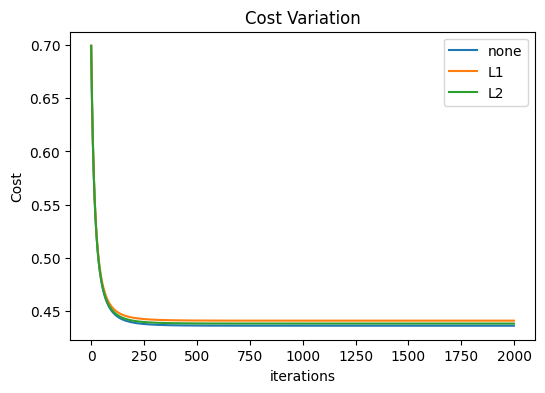

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(cost_none, label='none')
plt.plot(cost_l1, label='L1')
plt.plot(cost_l2, label='L2')
plt.title("Cost Variation")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [ ]:
print('none beta1:', np.round(beta1_none, 3))
print('L1   beta1:', np.round(beta1_l1, 3))
print('L2   beta1:', np.round(beta1_l2, 3))

none beta1: [-0.951  1.288 -0.516 -0.268 -0.07   0.092  0.083 -0.173]
L1   beta1: [-0.933  1.27  -0.494 -0.251 -0.06   0.081  0.072 -0.172]
L2   beta1: [-0.929  1.27  -0.503 -0.262 -0.068  0.099  0.08  -0.173]


## 2. Ensemble base learner: a small decision tree

A minimal Gini-based decision tree (configurable depth) used as the base estimator for bagging. A depth-1 special case (`DecisionStump`) is used as the weak learner for boosting.

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _gini(self, y):
        if len(y) == 0:
            return 0
        p = y.mean()
        return 1 - p**2 - (1 - p)**2

    def _best_split(self, X, y):
        n, m = X.shape
        best = {'gini': float('inf'), 'feature': None, 'threshold': None}
        for feature_i in range(m):
            for t in np.unique(X[:, feature_i]):
                left = X[:, feature_i] <= t
                right = ~left
                if left.sum() == 0 or right.sum() == 0:
                    continue
                gini = (left.sum() * self._gini(y[left]) + right.sum() * self._gini(y[right])) / n
                if gini < best['gini']:
                    best = {'gini': gini, 'feature': feature_i, 'threshold': t}
        return best if best['feature'] is not None else None

    def _build(self, X, y, depth):
        node = {'prediction': 1 if y.mean() >= 0.5 else 0}
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return node
        split = self._best_split(X, y)
        if split is None:
            return node
        left_mask = X[:, split['feature']] <= split['threshold']
        node.update({
            'feature': split['feature'],
            'threshold': split['threshold'],
            'left': self._build(X[left_mask], y[left_mask], depth + 1),
            'right': self._build(X[~left_mask], y[~left_mask], depth + 1)
        })
        return node

    def fit(self, X, y):
        self.tree = self._build(np.asarray(X, dtype=float), np.asarray(y, dtype=float), 0)
        return self

    def _predict_one(self, row, node):
        if 'feature' not in node:
            return node['prediction']
        branch = node['left'] if row[node['feature']] <= node['threshold'] else node['right']
        return self._predict_one(row, branch)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(row, self.tree) for row in X])


class DecisionStump(DecisionTree):
    """A depth-1 decision tree, used as the weak learner for AdaBoost."""
    def __init__(self):
        super().__init__(max_depth=1)

## 3. Simple Bagging

Trains `n_estimators` trees, each on a bootstrap sample of the training data, and averages their predictions.

In [ ]:
class SimpleBagging:
    def __init__(self, n_estimators=15, max_depth=3, sample_frac=1.0):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.sample_frac = sample_frac
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n = len(X)
        sample_size = int(n * self.sample_frac)
        self.trees = []
        for _ in range(self.n_estimators):
            idx = np.random.choice(n, size=sample_size, replace=True)
            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)
        return self

    def predict_proba(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        return preds.mean(axis=0)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [ ]:
bagging = SimpleBagging(n_estimators=25, max_depth=4, sample_frac=1.0)
bagging.fit(X_train_s, y_train_arr)
print('Bagging trained with', len(bagging.trees), 'trees')

Bagging trained with 25 trees


## 4. Simple Boosting (AdaBoost-style, decision stumps)

Classic discrete AdaBoost: each round, a stump is fit on a sample drawn according to the current example weights, its weighted error determines its vote strength (`alpha`), and misclassified examples get up-weighted for the next round.

In [ ]:
class AdaBoostScratch:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps = []
        self.alphas = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n = len(y)
        weights = np.ones(n) / n
        self.stumps, self.alphas = [], []

        for _ in range(self.n_estimators):
            idx = np.random.choice(n, size=n, replace=True, p=weights)
            stump = DecisionStump().fit(X[idx], y[idx])
            pred = stump.predict(X)

            miss = (pred != y).astype(float)
            error = np.clip(np.sum(weights * miss), 1e-10, 1 - 1e-10)
            alpha = 0.5 * np.log((1 - error) / error)

            y_signed = np.where(y == 1, 1, -1)
            pred_signed = np.where(pred == 1, 1, -1)
            weights *= np.exp(-alpha * y_signed * pred_signed)
            weights /= weights.sum()

            self.stumps.append(stump)
            self.alphas.append(alpha)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        agg = np.zeros(len(X))
        for stump, alpha in zip(self.stumps, self.alphas):
            pred_signed = np.where(stump.predict(X) == 1, 1, -1)
            agg += alpha * pred_signed
        return 1 / (1 + np.exp(-agg))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [ ]:
boosting = AdaBoostScratch(n_estimators=50)
boosting.fit(X_train_s, y_train_arr)
print('AdaBoost trained with', len(boosting.stumps), 'stumps')

AdaBoost trained with 50 stumps


## 5. Evaluation

Metrics used: **accuracy, precision, recall, F1, ROC-AUC** (5 metrics, above the required minimum of 4), plus confusion matrices and ROC curves for every model.

Each model is wrapped as a `(predict_proba_fn, predict_fn)` pair of plain functions taking only `X` — for the logistic models these close over the fitted `beta0`/`beta1`; for the ensembles they're just the bound `.predict_proba` / `.predict` methods. This lets one `evaluate()` function handle both the functional and object-based models identically.

In [ ]:
models_b = {
    'Logistic (none)': (
        lambda X: predict_proba(X, beta0_none, beta1_none),
        lambda X: predict(X, beta0_none, beta1_none),
    ),
    'Logistic (L1)': (
        lambda X: predict_proba(X, beta0_l1, beta1_l1),
        lambda X: predict(X, beta0_l1, beta1_l1),
    ),
    'Logistic (L2)': (
        lambda X: predict_proba(X, beta0_l2, beta1_l2),
        lambda X: predict(X, beta0_l2, beta1_l2),
    ),
    'Bagging': (bagging.predict_proba, bagging.predict),
    'AdaBoost': (boosting.predict_proba, boosting.predict),
}

def evaluate(predict_proba_fn, predict_fn, X, y):
    proba = predict_proba_fn(X)
    pred = predict_fn(X)
    return {
        'Accuracy': accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall': recall_score(y, pred),
        'F1': f1_score(y, pred),
        'ROC-AUC': roc_auc_score(y, proba),
    }, proba, pred

results_b = {}
proba_b = {}
pred_b = {}
for name, (proba_fn, pred_fn) in models_b.items():
    metrics, proba, pred = evaluate(proba_fn, pred_fn, X_test_s, y_test_arr)
    results_b[name] = metrics
    proba_b[name] = proba
    pred_b[name] = pred

results_b_df = pd.DataFrame(results_b).T.round(3)
results_b_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic (none),0.804,0.793,0.667,0.724,0.844
Logistic (L1),0.804,0.793,0.667,0.724,0.843
Logistic (L2),0.804,0.793,0.667,0.724,0.844
Bagging,0.810,0.843,0.623,0.717,0.841
AdaBoost,0.804,0.774,0.696,0.733,0.829


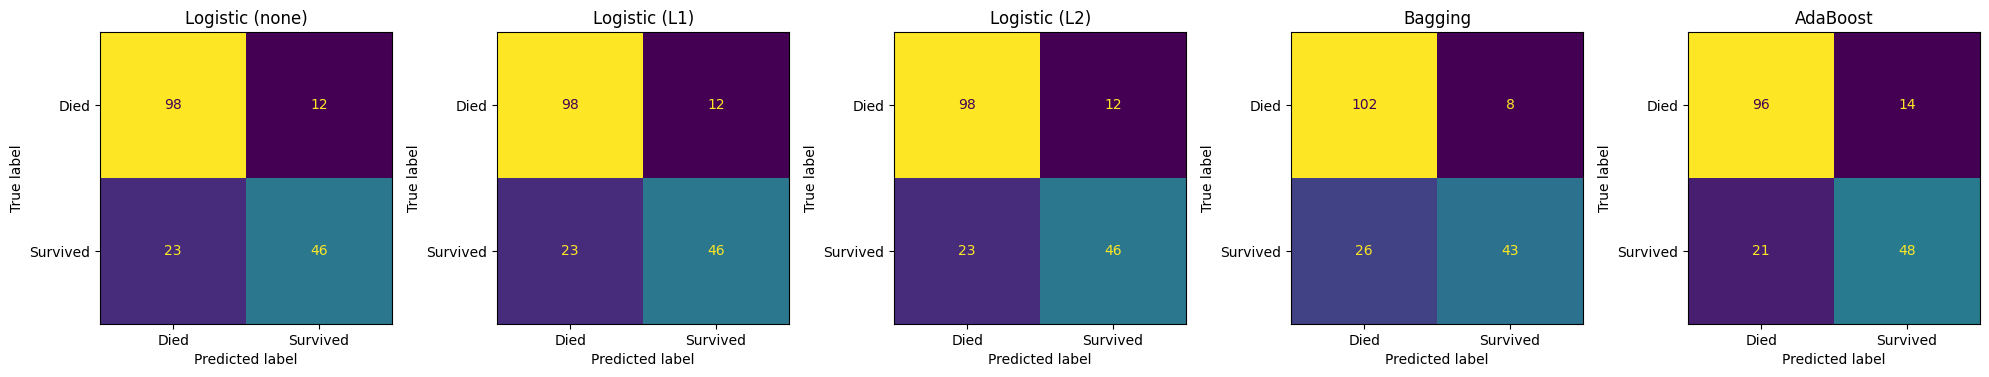

In [ ]:
fig, axes = plt.subplots(1, len(models_b), figsize=(4 * len(models_b), 4))
for ax, name in zip(axes, models_b):
    cm = confusion_matrix(y_test_arr, pred_b[name])
    ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

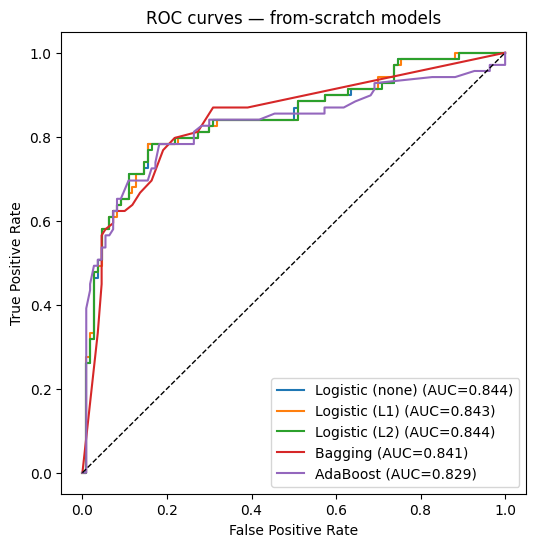

In [ ]:
plt.figure(figsize=(6, 6))
for name in models_b:
    fpr, tpr, _ = roc_curve(y_test_arr, proba_b[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results_b[name]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves — from-scratch models')
plt.legend()
plt.show()

## 6. Save results for comparison with Section C

In [ ]:
results_b_df.to_csv('section_b_results.csv')
results_b_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic (none),0.804,0.793,0.667,0.724,0.844
Logistic (L1),0.804,0.793,0.667,0.724,0.843
Logistic (L2),0.804,0.793,0.667,0.724,0.844
Bagging,0.810,0.843,0.623,0.717,0.841
AdaBoost,0.804,0.774,0.696,0.733,0.829
